In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

class Flow(nn.Module):
    """
    Simple flow model that takes in input tensor and time and outputs transformed tensor.
    Consists of 4 linear layers with ELU activations
    """
    def __init__(self, dim: int = 1, h: int = 64): 
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, method = 'euler') -> Tensor:
        """
        Calculate the probability density at a particular time step
        """
        if method == 'euler':
            t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
            update = self.forward(x_t=x_t, t=t_start)
            return x_t + update * (t_end - t_start)
            
        elif method == 'RK2':
            # Reshape t_start to be a column vector and expand to match the batch size of x_t
            t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
    
            # Translate x_t by the expected midpoint velocity between t_start and t_end
            start_vel = self.forward(x_t=x_t, t=t_start)
            midpoint_x = x_t + (start_vel * (t_end - t_start) / 2)
            midpoint_vel = self.forward(x_t=midpoint_x, t=t_start + (t_end - t_start) / 2)
    
            return x_t + (t_end - t_start) * midpoint_vel
    
    def clip_gradients(self, max_norm: float = 1.0):
        """
        Clip gradients to prevent exploding gradients
        """
        for param in self.parameters():
            if param.grad is not None:
                torch.nn.utils.clip_grad_norm_(param, max_norm)

In [2]:
from jetnet.datasets import JetNet
from jetnet.datasets.normalisations import FeaturewiseLinear

MASK = True
NUM_PARTICLES = 150
TRAIN_SPLIT = 0.7

data_args = {
    "jet_type": ["g", "q", "t", "w", "z"],
    "data_dir": "datasets/jetnet",
    "num_particles": NUM_PARTICLES, 
    "particle_features": (
        JetNet.ALL_PARTICLE_FEATURES if MASK else JetNet.ALL_PARTICLE_FEATURES[:-1]
    ),
    "jet_features": ["eta", "pt", "mass", "num_particles", "type"],
    "jet_normalisation": FeaturewiseLinear(),
    "split_fraction": [TRAIN_SPLIT, 1 - TRAIN_SPLIT, 0],
    "download": True
}
X_train = JetNet(
    jet_type=data_args["jet_type"],
    data_dir=data_args["data_dir"],
    num_particles=data_args["num_particles"],
    particle_features=data_args["particle_features"],
    jet_features=data_args["jet_features"],
    split_fraction=data_args["split_fraction"],
    jet_normalisation=data_args["jet_normalisation"],
    split="train",
    download=True
)

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [3]:
from util.coordinates import transform_rel_particle_coordinates_to_cartesian
X_train_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_train).to('cpu')

In [4]:
particle_clouds = X_train_particle_transformed[:, :, :4]
masks = X_train_particle_transformed[:, :, 4]
masked_clouds = (masks.unsqueeze(-1) * particle_clouds)
masked_clouds_flat = masked_clouds.flatten(start_dim=0, end_dim=1)
non_zero_mask = (masked_clouds_flat != 0).any(dim=1)
masked_clouds_flat = masked_clouds_flat[non_zero_mask]
min_std = np.min(np.std(masked_clouds_flat.numpy(), axis=0))
masked_clouds_flat = masked_clouds_flat / min_std

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
num_samples = 5000
ratio = 0.8
n_train = int(num_samples * ratio)
x_1 = masked_clouds_flat[torch.randperm(num_samples)]
x_1 = x_1.to(device)

In [7]:
flow_model = Flow(dim=4, h=256).to(device)

In [8]:
x_1_train = x_1[:n_train]
x_1_val = x_1[n_train:]

val_time_1 = torch.Tensor([0.1])
val_time_2 = torch.Tensor([0.9])
val_times_1 = val_time_1.expand(x_1_val.shape[0], -1).to(device)
val_times_2 = val_time_2.expand(x_1_val.shape[0], -1).to(device)
val_times_1.shape, val_times_2.shape

(torch.Size([1000, 1]), torch.Size([1000, 1]))

In [9]:
lr = 1e-2
weight_decay = 1e-1
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay, fused=True)
loss_fn = nn.MSELoss()

x_0_dist_mean = torch.tensor([0.0])
x_0_dist_std = torch.tensor([1.5])
num_epochs = 20000
losses = []

val_losses_1 = []
val_losses_2 = []
for epoch in range(num_epochs):
    x_0 = (torch.randn(len(x_1_train), 1) * x_0_dist_std + x_0_dist_mean).to(device)
    t = torch.rand(len(x_1_train), 1, device=device)
    x_t = (1 - t) * x_0 + t * x_1_train
    dx_t = x_1_train - x_0
    optimizer.zero_grad()
    loss = loss_fn(flow_model(t=t, x_t=x_t), dx_t)

    x_0_val = torch.randn(len(x_1_val), 1) * x_0_dist_std + x_0_dist_mean

    x_t_val_1 = (1 - val_times_1) * x_0_val + val_times_1 * x_1_val
    dx_t_val_1 = x_1_val - x_0_val
    val_loss_1 = loss_fn(flow_model(t=val_times_1, x_t=x_t_val_1), dx_t_val_1)

    x_t_val_2 = (1 - val_times_2) * x_0_val + val_times_2 * x_1_val
    dx_t_val_2 = x_1_val - x_0_val
    val_loss_2 = loss_fn(flow_model(t=val_times_2, x_t=x_t_val_2), dx_t_val_2)

    val_losses_1.append(val_loss_1.item())
    val_losses_2.append(val_loss_2.item())
    
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    
    flow_model.clip_gradients(max_norm=1.0)

    if (epoch) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}, Val loss: t=0.1 {val_loss_1.item():.4f}, t=0.9 {val_loss_2.item():.4f}")

print("Training complete.")

Epoch 1/20000, Loss: 3.9489, Val loss: t=0.1 4.6445, t=0.9 4.6573
Epoch 1001/20000, Loss: 2.2113, Val loss: t=0.1 2.4087, t=0.9 3.4260
Epoch 2001/20000, Loss: 2.1506, Val loss: t=0.1 2.4575, t=0.9 3.3663
Epoch 3001/20000, Loss: 2.1594, Val loss: t=0.1 2.3913, t=0.9 3.2922
Epoch 4001/20000, Loss: 2.2043, Val loss: t=0.1 2.4485, t=0.9 3.6087
Epoch 5001/20000, Loss: 2.1874, Val loss: t=0.1 2.5696, t=0.9 3.4127
Epoch 6001/20000, Loss: 274.9934, Val loss: t=0.1 273.3667, t=0.9 273.3667
Epoch 7001/20000, Loss: 51.8164, Val loss: t=0.1 53.3820, t=0.9 53.3820
Epoch 8001/20000, Loss: 6.9324, Val loss: t=0.1 7.6451, t=0.9 7.6451
Epoch 9001/20000, Loss: 1802.5143, Val loss: t=0.1 1807.7288, t=0.9 1807.7288
Epoch 10001/20000, Loss: 1696.9706, Val loss: t=0.1 1694.3192, t=0.9 1694.3192
Epoch 11001/20000, Loss: 1534.4313, Val loss: t=0.1 1531.4513, t=0.9 1531.4513
Epoch 12001/20000, Loss: 1305.3340, Val loss: t=0.1 1307.3030, t=0.9 1307.3030
Epoch 13001/20000, Loss: 1001.0480, Val loss: t=0.1 999.94

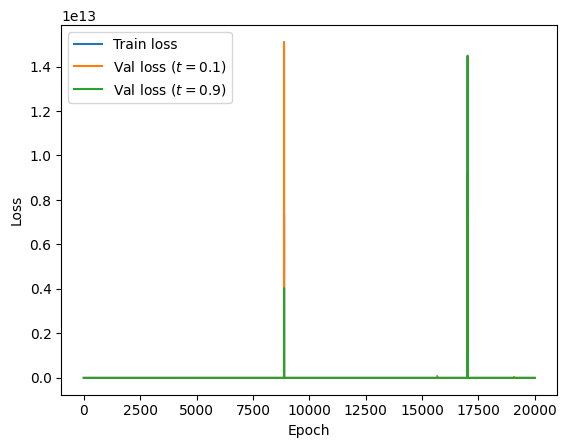

In [10]:
sns.lineplot(x=range(len(losses)), y=losses, label="Train loss")
sns.lineplot(x=range(len(val_losses_1)), y=val_losses_1, label=r"Val loss ($t=0.1$)")
sns.lineplot(x=range(len(val_losses_2)), y=val_losses_2, label=r"Val loss ($t=0.9$)")
plt.xlabel("Epoch") 
plt.ylabel("Loss")
plt.savefig("losses.png")

In [11]:
def simulate_trajectory(flow_model: Flow, x_start: Tensor, t_start: float, t_end: float, num_steps: int = 50) -> Tensor:
    dt = (t_end - t_start) / num_steps
    x_current = x_start.clone().detach()
    
    for i in range(num_steps):
        t_current = t_start + i * dt
        t_next = t_current + dt
        x_current = flow_model.step(x_current, 
                                  torch.tensor(t_current, dtype=torch.float32), 
                                  torch.tensor(t_next, dtype=torch.float32))
    
    return x_current

In [12]:
from IPython.display import HTML
from scipy.stats import gaussian_kde 
import matplotlib.animation as animation

BANDWIDTH = 0.3

def create_flow_evolution_video(flow_model, initial_gaussian_samples, x_1, simulate_trajectory, save_path):
    flow_model.eval()

    x_min_plot = min(initial_gaussian_samples.min().item(), x_1.min().item()) - 0.5
    x_max_plot = max(initial_gaussian_samples.max().item(), x_1.max().item()) + 0.5
    

    num_time_slices = 100 
    time_points = np.linspace(0, 1, num_time_slices)
    num_x_points = 200
    x_grid = np.linspace(x_min_plot, x_max_plot, num_x_points)
    
    density_matrix = np.zeros((num_time_slices, num_x_points))
    with torch.no_grad():
        for i, t_val in enumerate(time_points):
            if i % 10 == 0:
                print(f"Time step {i+1}/{num_time_slices}")
            if t_val == 0:
                current_x_samples = initial_gaussian_samples.cpu().numpy().flatten()
            else:
                current_x_samples = simulate_trajectory(flow_model, initial_gaussian_samples, 0, t_val, num_steps=50).cpu().numpy().flatten()
            
            kde = gaussian_kde(current_x_samples, bw_method=BANDWIDTH)
            density_matrix[i, :] = kde(x_grid)
    
    max_density = density_matrix.max()
    if max_density > 0:
        density_matrix /= max_density
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left plot
    im = ax1.imshow(np.zeros((num_x_points, 1)), aspect='auto', origin='lower', 
                   cmap='viridis', extent=[0, 0, x_min_plot, x_max_plot],
                   vmin=0, vmax=1)
    
    ax1.set_xlabel('Time (t)')
    ax1.set_ylabel('x')
    ax1.set_title('Density Heatmap')
    plt.colorbar(im, ax=ax1, label='Normalized Probability Density')
    
    # Right plot: Current time step PDF with target reference
    target_kde = gaussian_kde(x_1.cpu().numpy().flatten(), bw_method=BANDWIDTH)
    target_density = target_kde(x_grid)
    target_density /= target_density.max()
    ax2.plot(x_grid, target_density, 'r-', linewidth=2, label='Target (t=1)', alpha=0.7)
    ax2.fill_between(x_grid, target_density, alpha=0.3, color='red')
    
    # Current distribution 
    line_current, = ax2.plot([], [], 'g-', linewidth=3, label='Current')
    ax2.set_xlim(x_min_plot, x_max_plot)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Normalized Density')
    ax2.set_title('Current vs Target Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    time_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=14,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    def animate(frame):
        current_time_slice = frame + 1
        current_density_matrix = density_matrix[:current_time_slice, :].T
        current_time_extent = time_points[current_time_slice - 1]
        im.set_array(current_density_matrix)
        im.set_extent([0, current_time_extent, x_min_plot, x_max_plot])
        ax1.set_xlim(0, 1.0) 
        current_density = density_matrix[frame, :]
        t_val = time_points[frame]
        
        line_current.set_data(x_grid, current_density)

        for collection in ax2.collections:
            collection.remove()
        ax2.fill_between(x_grid, current_density, alpha=0.5, color='green')

        time_text.set_text(f't = {t_val:.3f}')
        
        return im, line_current, time_text    

    anim = animation.FuncAnimation(fig, animate, frames=num_time_slices, 
                                 interval=100, blit=False, repeat=True)
    
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=10, metadata=dict(artist='Flow Matching'), bitrate=1800)
    anim.save(save_path, writer=writer)
    plt.close(fig)

    return anim

In [13]:
num_plot_samples = 5000
# generate 4-d gaussian
initial_gaussian_samples = torch.randn(num_plot_samples, 4) * x_0_dist_std + x_0_dist_mean

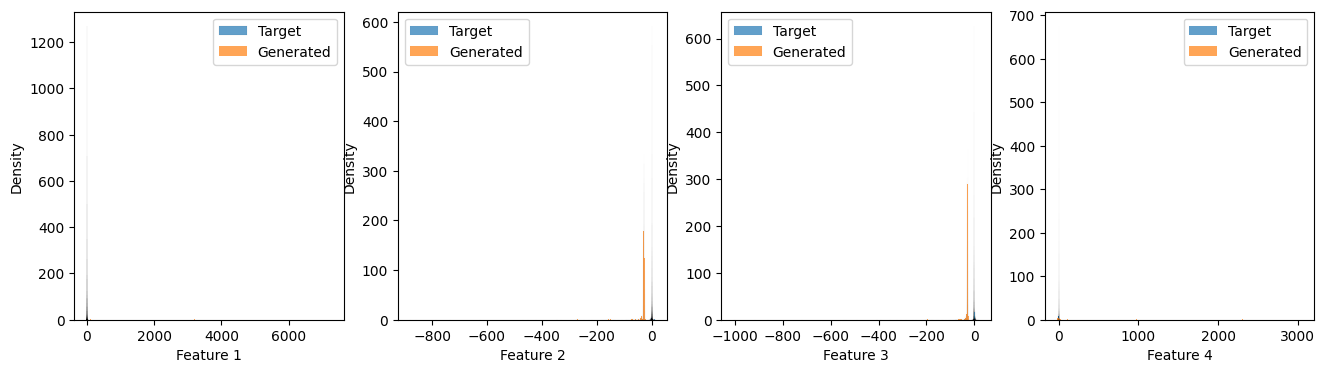

In [17]:
final_samples = simulate_trajectory(flow_model, initial_gaussian_samples, 0, 1.0, num_steps=64)
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    sns.histplot(x_1.cpu().numpy()[:, i], alpha=0.7, label='Target', ax=axs[i])
    sns.histplot(final_samples.detach().numpy()[:, i], alpha=0.7, label='Generated', ax=axs[i])
    axs[i].legend()
    axs[i].set_xlabel(f'Feature {i+1}')
    axs[i].set_ylabel('Density')

In [15]:
anim = create_flow_evolution_video(flow_model, initial_gaussian_samples, x_1, simulate_trajectory, save_path='flow_evolution.mp4')
HTML(anim.to_jshtml())
plt.show()

Time step 1/100
Time step 11/100
Time step 21/100
Time step 31/100
Time step 41/100
Time step 51/100
Time step 61/100
Time step 71/100
Time step 81/100
Time step 91/100


/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_46899/2154015412.py:39: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax1.imshow(np.zeros((num_x_points, 1)), aspect='auto', origin='lower',
/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_46899/2154015412.py:72: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im.set_extent([0, current_time_extent, x_min_plot, x_max_plot])


In [25]:
masked_clouds_flat.shape

torch.Size([30447346, 4])